# NYPD Shooting Incidents Data 2006-2025

##Data Overview

In [278]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#read csv file

df = pd.read_csv('https://raw.githubusercontent.com/rs243/PythonDataAnalytics/refs/heads/main/NYPD_Shooting_Incident_Data_(Historic)_20251206.csv')
df.head()


,INCIDENT_KEY,OCCUR_DATE,OCCUR_TIME,BORO,LOC_OF_OCCUR_DESC,PRECINCT,PERP_AGE_GROUP,PERP_SEX,VIC_AGE_GROUP,VIC_SEX
0,298699604,12/31/2024,19:16:00,BROOKLYN,OUTSIDE,69,25-44,M,18-24,M
1,298699604,12/31/2024,19:16:00,BROOKLYN,OUTSIDE,69,25-44,M,25-44,M
2,298672096,12/30/2024,16:45:00,BRONX,OUTSIDE,47,(null),(null),18-24,M
3,298672094,12/30/2024,12:15:00,BRONX,OUTSIDE,52,45-64,M,25-44,M
4,298672097,12/30/2024,18:48:00,BROOKLYN,OUTSIDE,60,25-44,M,45-64,M


In [279]:
#data types

df.dtypes


,0
INCIDENT_KEY,int64
OCCUR_DATE,object
OCCUR_TIME,object
BORO,object
LOC_OF_OCCUR_DESC,object
PRECINCT,int64
PERP_AGE_GROUP,object
PERP_SEX,object
VIC_AGE_GROUP,object
VIC_SEX,object


In [280]:
#shape of the dataframe

df.shape


(29744, 10)

In [281]:
#cleaning column names

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace('-', '_')
)
df.columns


Index(['incident_key', 'occur_date', 'occur_time', 'boro', 'loc_of_occur_desc',
       'precinct', 'perp_age_group', 'perp_sex', 'vic_age_group', 'vic_sex'],
      dtype='object')

In [282]:
df

,incident_key,occur_date,occur_time,boro,loc_of_occur_desc,precinct,perp_age_group,perp_sex,vic_age_group,vic_sex
0,298699604,12/31/2024,19:16:00,BROOKLYN,OUTSIDE,69,25-44,M,18-24,M
1,298699604,12/31/2024,19:16:00,BROOKLYN,OUTSIDE,69,25-44,M,25-44,M
2,298672096,12/30/2024,16:45:00,BRONX,OUTSIDE,47,(null),(null),18-24,M
3,298672094,12/30/2024,12:15:00,BRONX,OUTSIDE,52,45-64,M,25-44,M
4,298672097,12/30/2024,18:48:00,BROOKLYN,OUTSIDE,60,25-44,M,45-64,M
...,...,...,...,...,...,...,...,...,...,...
29739,9953247,01/01/2006,03:30:00,BROOKLYN,NaN,67,UNKNOWN,U,18-24,M
29740,9953248,01/01/2006,19:00:00,QUEENS,NaN,106,18-24,M,18-24,M
29741,9953250,01/01/2006,02:34:00,QUEENS,NaN,114,18-24,M,25-44,M
29742,9953246,01/01/2006,05:51:00,BRONX,NaN,44,25-44,M,18-24,M


In [283]:
#replacing the values '(null)' 'U' and 'UNKNOWN' with 'NaN' for all columns

df_nypd = df.replace(['UNKNOWN', '(null)', 'U'], np.nan)
print(df_nypd)


       incident_key  occur_date occur_time      boro loc_of_occur_desc  \
0         298699604  12/31/2024   19:16:00  BROOKLYN           OUTSIDE   
1         298699604  12/31/2024   19:16:00  BROOKLYN           OUTSIDE   
2         298672096  12/30/2024   16:45:00     BRONX           OUTSIDE   
3         298672094  12/30/2024   12:15:00     BRONX           OUTSIDE   
4         298672097  12/30/2024   18:48:00  BROOKLYN           OUTSIDE   
...             ...         ...        ...       ...               ...   
29739       9953247  01/01/2006   03:30:00  BROOKLYN               NaN   
29740       9953248  01/01/2006   19:00:00    QUEENS               NaN   
29741       9953250  01/01/2006   02:34:00    QUEENS               NaN   
29742       9953246  01/01/2006   05:51:00     BRONX               NaN   
29743     139716503  01/01/2006   12:30:00  BROOKLYN               NaN   

       precinct perp_age_group perp_sex vic_age_group vic_sex  
0            69          25-44        M        

In [284]:
#number of rows missing in each column

df_nypd.isnull().sum().sort_values(ascending=False)


,0
loc_of_occur_desc,25596
perp_age_group,14120
perp_sex,12438
vic_age_group,68
vic_sex,12
incident_key,0
occur_date,0
precinct,0
occur_time,0
boro,0


In [285]:
#% of rows missing in each column

for column in df_nypd.columns:
    percentage = df_nypd[column].isnull().mean()
    print(column + ' : ' + str(round(percentage*100,2)))


incident_key : 0.0
occur_date : 0.0
occur_time : 0.0
boro : 0.0
loc_of_occur_desc : 86.05
precinct : 0.0
perp_age_group : 47.47
perp_sex : 41.82
vic_age_group : 0.23
vic_sex : 0.04


##Dealing with Missing Data

In [286]:
#finding the mode value of the columns

df_nypd['loc_of_occur_desc'].mode()


,loc_of_occur_desc
0,OUTSIDE


In [287]:
#use fillna() to replace NaN in loc_of_occur_desc column by the mean, median (numeric data) or mode

mode_loc_of_occur_desc = df_nypd['loc_of_occur_desc'].mode()[0]
df_nypd['loc_of_occur_desc'] = df_nypd['loc_of_occur_desc'].fillna(mode_loc_of_occur_desc)
df_nypd.isnull().sum()


,0
incident_key,0
occur_date,0
occur_time,0
boro,0
loc_of_occur_desc,0
precinct,0
perp_age_group,14120
perp_sex,12438
vic_age_group,68
vic_sex,12


In [288]:
#finding the mode value of the columns

df_nypd['perp_age_group'].mode()


,perp_age_group
0,18-24


In [289]:
#use fillna() to replace NaN in perp_age_group column by the mean, median (numeric data) or mode

mode_perp_age_group = df_nypd['perp_age_group'].mode()[0]
df_nypd['perp_age_group'] = df_nypd['perp_age_group'].fillna(mode_perp_age_group)
df_nypd.isnull().sum()


,0
incident_key,0
occur_date,0
occur_time,0
boro,0
loc_of_occur_desc,0
precinct,0
perp_age_group,0
perp_sex,12438
vic_age_group,68
vic_sex,12


In [290]:
#finding the mode value of the columns

df_nypd['perp_sex'].mode()


,perp_sex
0,M


In [291]:
#use fillna() to replace NaN in perp_sex column by the mean, median (numeric data) or mode

mode_perp_sex = df_nypd['perp_sex'].mode()[0]
df_nypd['perp_sex'] = df_nypd['perp_sex'].fillna(mode_perp_sex)
df_nypd.isnull().sum()


,0
incident_key,0
occur_date,0
occur_time,0
boro,0
loc_of_occur_desc,0
precinct,0
perp_age_group,0
perp_sex,0
vic_age_group,68
vic_sex,12


In [292]:
#finding the mode value of the columns

df_nypd['vic_age_group'].mode()


,vic_age_group
0,25-44


In [293]:
#use fillna() to replace NaN in vic_age_group column by the mean, median (numeric data) or mode

mode_vic_age_group = df_nypd['vic_age_group'].mode()[0]
df_nypd['vic_age_group'] = df_nypd['vic_age_group'].fillna(mode_vic_age_group)
df_nypd.isnull().sum()


,0
incident_key,0
occur_date,0
occur_time,0
boro,0
loc_of_occur_desc,0
precinct,0
perp_age_group,0
perp_sex,0
vic_age_group,0
vic_sex,12


In [294]:
#finding the mode value of the columns

df_nypd['vic_sex'].mode()


,vic_sex
0,M


In [295]:
#use fillna() to replace NaN in vic_sex column by the mean, median (numeric data) or mode

mode_vic_sex = df_nypd['vic_sex'].mode()[0]
df_nypd['vic_sex'] = df_nypd['vic_sex'].fillna(mode_vic_sex)
df_nypd.isnull().sum()


,0
incident_key,0
occur_date,0
occur_time,0
boro,0
loc_of_occur_desc,0
precinct,0
perp_age_group,0
perp_sex,0
vic_age_group,0
vic_sex,0


In [296]:
df_nypd

,incident_key,occur_date,occur_time,boro,loc_of_occur_desc,precinct,perp_age_group,perp_sex,vic_age_group,vic_sex
0,298699604,12/31/2024,19:16:00,BROOKLYN,OUTSIDE,69,25-44,M,18-24,M
1,298699604,12/31/2024,19:16:00,BROOKLYN,OUTSIDE,69,25-44,M,25-44,M
2,298672096,12/30/2024,16:45:00,BRONX,OUTSIDE,47,18-24,M,18-24,M
3,298672094,12/30/2024,12:15:00,BRONX,OUTSIDE,52,45-64,M,25-44,M
4,298672097,12/30/2024,18:48:00,BROOKLYN,OUTSIDE,60,25-44,M,45-64,M
...,...,...,...,...,...,...,...,...,...,...
29739,9953247,01/01/2006,03:30:00,BROOKLYN,OUTSIDE,67,18-24,M,18-24,M
29740,9953248,01/01/2006,19:00:00,QUEENS,OUTSIDE,106,18-24,M,18-24,M
29741,9953250,01/01/2006,02:34:00,QUEENS,OUTSIDE,114,18-24,M,25-44,M
29742,9953246,01/01/2006,05:51:00,BRONX,OUTSIDE,44,25-44,M,18-24,M


##Converting columns into datetime and category

In [297]:
#converting columns which should be category into category data type

categorical_cols = ['boro', 'loc_of_occur_desc', 'perp_age_group', 'perp_sex', 'vic_age_group', 'vic_sex']

for col in categorical_cols:
    df_nypd[col] = df_nypd[col].astype('category')

df_nypd[categorical_cols].dtypes


,0
boro,category
loc_of_occur_desc,category
perp_age_group,category
perp_sex,category
vic_age_group,category
vic_sex,category


In [298]:
#converting columns which should be date time into datetime data type

df_nypd['occur_date'] = pd.to_datetime(df_nypd['occur_date'], errors='coerce')
df_nypd['occur_time'] = pd.to_datetime(df_nypd['occur_time'], errors='coerce')

df_nypd.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29744 entries, 0 to 29743
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   incident_key       29744 non-null  int64         
 1   occur_date         29744 non-null  datetime64[ns]
 2   occur_time         29744 non-null  datetime64[ns]
 3   boro               29744 non-null  category      
 4   loc_of_occur_desc  29744 non-null  category      
 5   precinct           29744 non-null  int64         
 6   perp_age_group     29744 non-null  category      
 7   perp_sex           29744 non-null  category      
 8   vic_age_group      29744 non-null  category      
 9   vic_sex            29744 non-null  category      
dtypes: category(6), datetime64[ns](2), int64(2)
memory usage: 1.1 MB


/tmp/ipython-input-1015818896.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_nypd['occur_time'] = pd.to_datetime(df_nypd['occur_time'], errors='coerce')


##Univariate Analysis

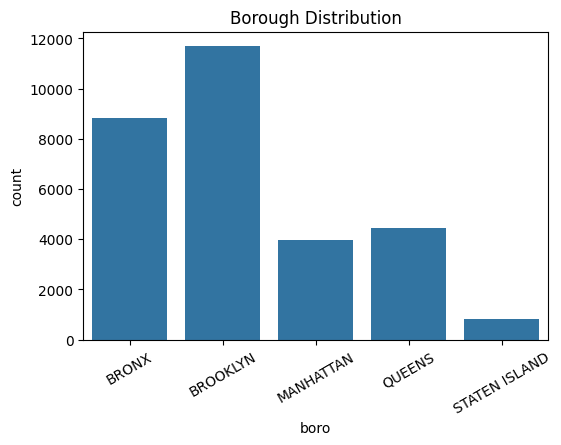

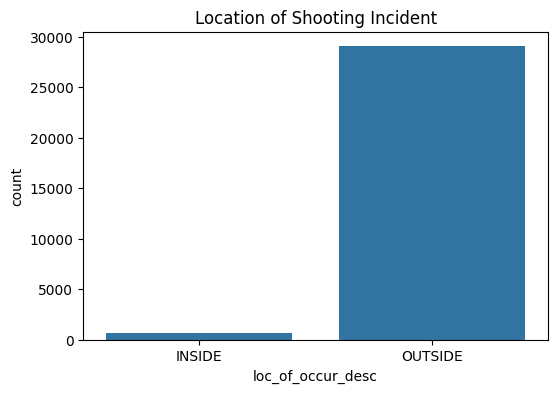

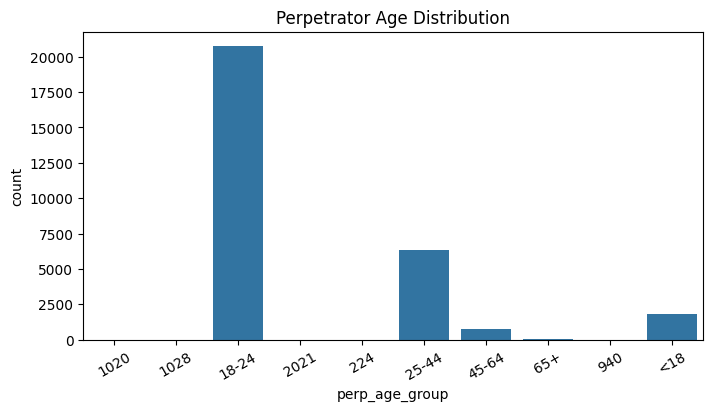

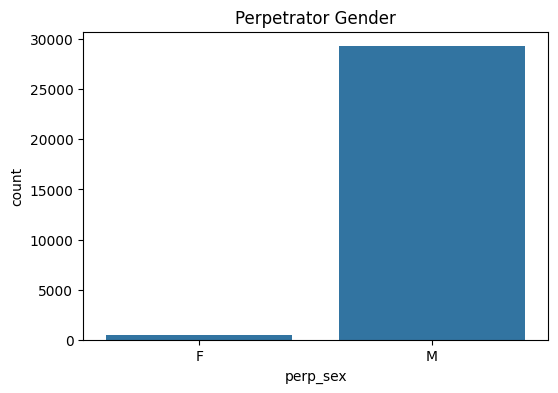

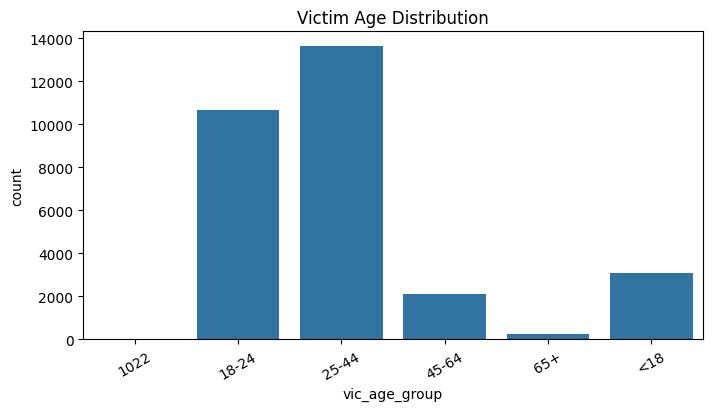

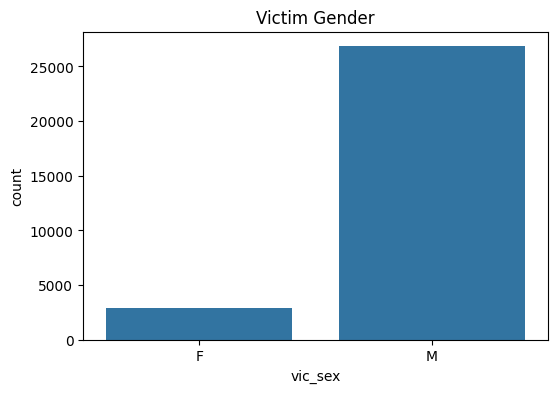

In [299]:
plt.figure(figsize=(6, 4))
sns.countplot(x='boro', data=df_nypd)
plt.title('Borough Distribution')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='loc_of_occur_desc', data=df_nypd)
plt.title('Location of Shooting Incident')
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x='perp_age_group', data=df_nypd)
plt.title('Perpetrator Age Distribution')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='perp_sex', data=df_nypd)
plt.title('Perpetrator Gender')
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(x='vic_age_group', data=df_nypd)
plt.title('Victim Age Distribution')
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='vic_sex', data=df_nypd)
plt.title('Victim Gender')
plt.show()

##Bivariate Analysis

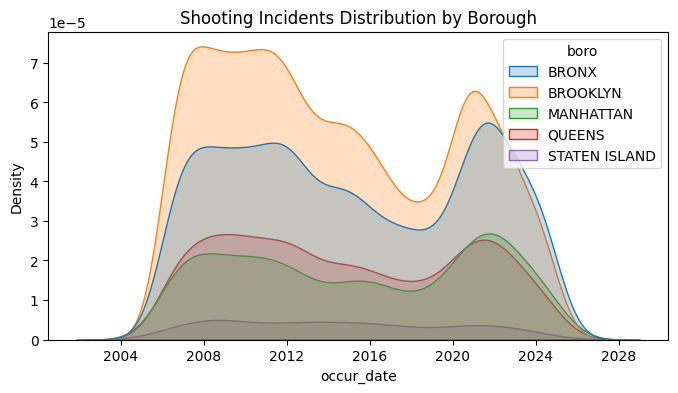

In [300]:
#Shooting incidents distribution by borough

plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_nypd, x='occur_date', hue='boro', fill=True)
plt.title('Shooting Incidents Distribution by Borough')
plt.show()


Analysis

In the plots we can see that in the years since 2006 Brooklyn has the highest number of shooting incidents followed by Bronx where majority of shooting took place outside.
The majority of perpetrator falls in the 18-24 age group, followed by 25-44 age group where male clearly dominates the gender.
The highest number of victims falls in the 25-44 age group followed by 18-24 age group with male being the dominant.
The KDE plot shows the trend of shooting incidents since 2006 in each borough where Brooklyn generally has the higher density of incidents over the years.
Bias may have occurred while filling in the missing values with the mode values of the columns.

In [301]:
#saving file

output_file = 'Python-project2-cleaned.csv'
df.to_csv(output_file, index=False)
print(f'Cleaned data saved to: {output_file}')


Cleaned data saved to: Python-project2-cleaned.csv
